# Week 1 Assignment – AI & ML Foundations

## Titanic Dataset Analysis and Data Cleaning

**Name:** Yashi Jain  

### Objective
The goal of this assignment is to explore and clean a dataset using Python and Pandas while performing basic exploratory data analysis.

### Tasks Performed
- Load dataset using Pandas
- Inspect dataset structure
- Handle missing values
- Standardize column names
- Remove duplicate records
- Perform exploratory data analysis (EDA)
- Save cleaned dataset

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


#Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Dataset Overview

In [3]:
# Dataset shape

df.shape

(891, 12)

In [4]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Column names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

#Check Missing Values

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#Handle Missing Values

In [11]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop(columns=['Cabin'], errors='ignore')

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Remove Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

#Clean Column Names

In [15]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'embarked'],
      dtype='object')

#Exploratory Data Analysis

Survival Distribution

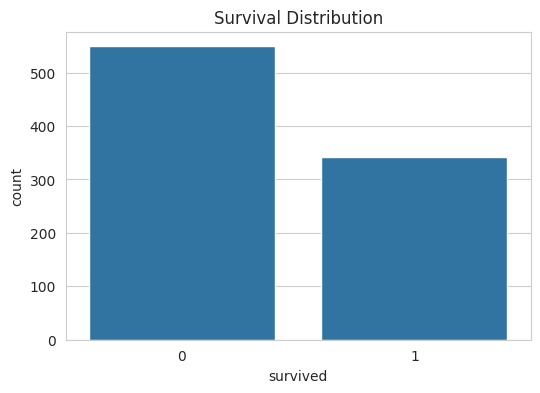

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="survived", data=df)

plt.title("Survival Distribution")

plt.show()

Survival by Gender

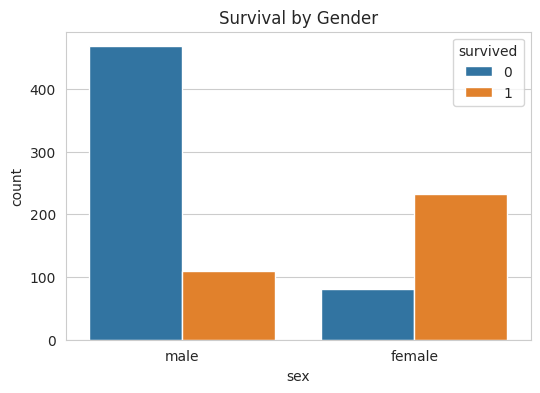

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", hue="survived", data=df)

plt.title("Survival by Gender")

plt.show()

Age Distribution

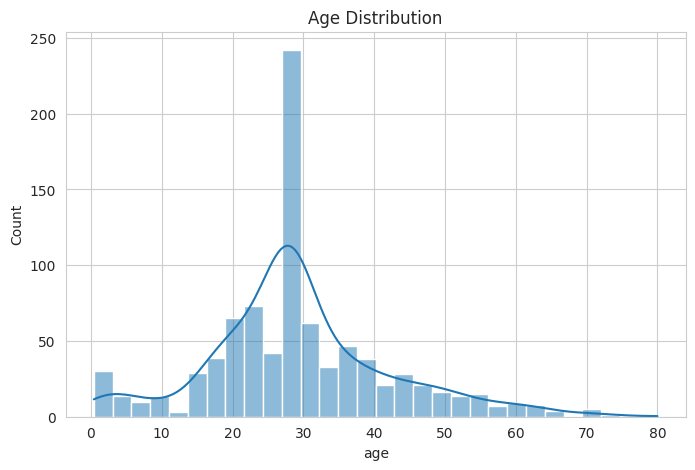

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

Passenger Class VS Survival

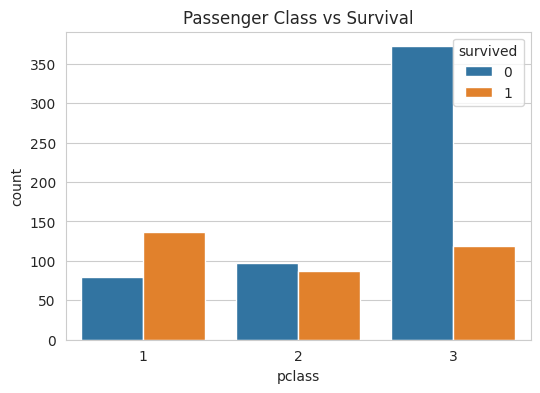

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="pclass", hue="survived", data=df)

plt.title("Passenger Class vs Survival")

plt.show()

Face vs Survival

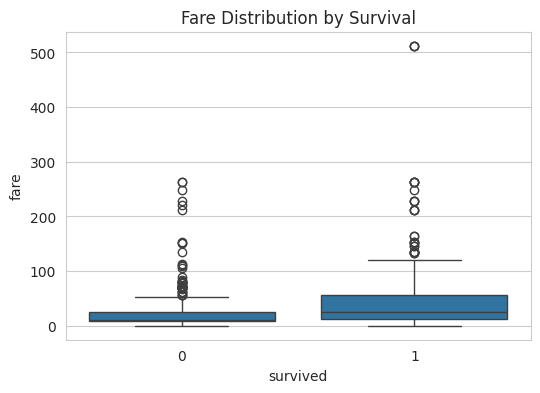

In [20]:
plt.figure(figsize=(6,4))

sns.boxplot(x="survived", y="fare", data=df)

plt.title("Fare Distribution by Survival")

plt.show()

Correlation Heatmap

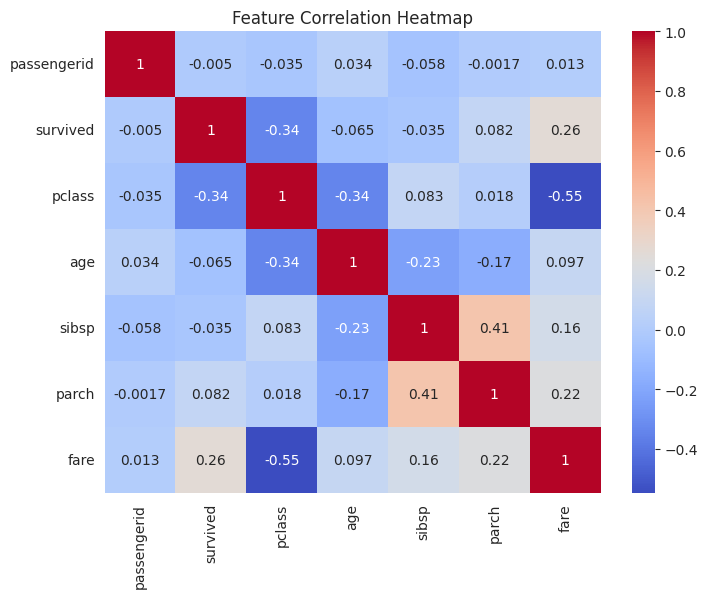

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

Key Insights

1. Female passengers had a higher survival rate compared to male passengers.

2. Passengers traveling in first class had a better chance of survival.

3. Most passengers were between 20 and 40 years old.

4. Fare price has some correlation with passenger class and survival.

5. Lower passenger classes had lower survival rates.



#Save Cleaned Dataset

In [22]:
# Save cleaned dataset

df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


#Download Cleaned Dataset

In [23]:
from google.colab import files

files.download("cleaned_titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This notebook demonstrated the process of data preprocessing and exploratory data analysis using the Titanic dataset.

The dataset was inspected, cleaned, and analyzed to identify patterns affecting passenger survival. These preprocessing steps are important before applying machine learning models.

Future work could involve building predictive models to estimate survival probabilities using machine learning techniques.